# Day 5

## Advanced methods and neural networks

Notebook prepared by Nuno R. C. Gomes, IEEC/ICE-CSIC | v20260507

###### Cerdanyola del Vallès, Barcelona, 18-22 May 2026

----

Welcome to **Day 5** of our Machine Learning for Scientific Research course! 🔬

Today, we dive deeper into the world of **neural networks**—powerful tools that can uncover patterns in complex scientific data.
Neural networks typically extend beyond basic models. 🧬

We will explore strategies for building and training **multilayer perceptrons** (MLPs), handling challenges such as **small data sets** through augmentation, and constructing **modular networks** using Keras/TensorFlow and PyTorch (advanced lab).

By the end of this notebook, you will be able to design, train, and evaluate neural networks effectively, while visualising their learning dynamics and applying practical strategies to improve performance in real scientific applications.

## Imports

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import random
import seaborn as sns
from sklearn.datasets import load_digits, make_classification
from sklearn.metrics import (
  classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Input, layers, models
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms

## Configuration

In [33]:
# random seed
SEED = 42
# learning rate
LR = 0.001
# torch
torch.manual_seed(SEED)
np.random.seed(SEED)

## Single-layer perceptron with TensorFlow

We build a Perceptron using TensorFlow to understand how a basic neural network works.

In [ ]:
# create simple data set with two features for binary classification
# split it into training and testing sets
X, y = make_classification(
  n_samples=1000,
  n_features=2,
  n_informative=2,
  n_redundant=0,
  n_repeated=0,
  n_classes=2,
  random_state=SEED
)

# train/test split
X_trn, X_tst, y_trn, y_tst = train_test_split(
  X, y, test_size=0.2, random_state=SEED
)

# standardise data
scaler = StandardScaler()
X_trn = scaler.fit_transform(X_trn)
X_tst = scaler.transform(X_tst)

# build single layer perceptron using sequential model with one dense layer
# sigmoid activation is used to produce outputs between 0 and 1 for
# binary classification
model = tf.keras.Sequential([
  tf.keras.Input(shape=(2, )),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# build neural network
model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)

# train model
history = model.fit(
  X_trn, y_trn,
  epochs=50,
  batch_size=16,
  validation_split=0.1,
  verbose=0
)

# evaluate model
loss, accuracy = model.evaluate(X_tst, y_tst, verbose=0)
print(f"Test accuracy: {accuracy:.2f}")

Test accuracy: 0.88


## Multi-layer perceptron with TensorFlow

We will build a simple neural network using TensorFlow.

In [3]:
# data
(x_trn, y_trn), (x_tst, y_tst) = tf.keras.datasets.mnist.load_data()

# normalise image data
gray_scale = 255

x_trn = x_trn.astype('float32') / gray_scale
x_tst = x_tst.astype('float32') / gray_scale

print("Feature matrix (x_trn):", x_trn.shape)
print("Target matrix (y_trn):", y_trn.shape)
print("Feature matrix (x_tst):", x_tst.shape)
print("Target matrix (y_tet):", y_tst.shape)

Feature matrix (x_trn): (60000, 28, 28)
Target matrix (y_trn): (60000,)
Feature matrix (x_tst): (10000, 28, 28)
Target matrix (y_tet): (10000,)


To understand the data better, we plot the first 100 training samples, each representing a digit.

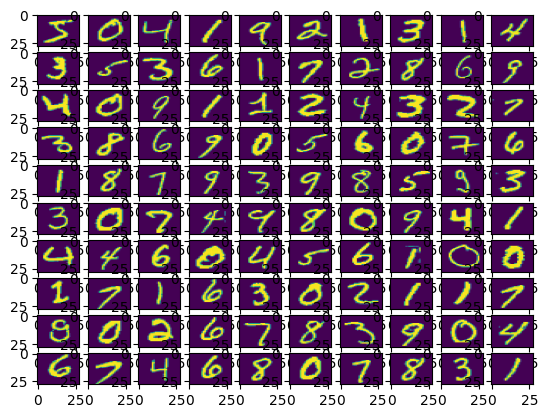

In [4]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
  for j in range(10):
    ax[i][j].imshow(x_trn[k].reshape(28, 28), aspect='auto')
    k += 1

We now build a sequential neural network model.
The model consists of:

- **Flatten layer**: reshapes 2D input (28x28 pixels) into a 1D array of 784 elements.
- **Dense layers**: fully connected layers with 256 and 128 neurons, both using the relu-activation function.
- **Output layer**: the final layer with 10 neurons representing the 10 classes of digits (0-9) with sigmoid activation.

In [9]:
model = Sequential([
  Input(shape=(28, 28)),
  Flatten(),
  Dense(256, activation='relu'),
  Dense(128, activation='relu'),
  Dense(10, activation='softmax'),
])

Once the model is defined, we compile it by specifying:

- **Optimiser**: Adam for efficient weight updates.
- **Loss function**: sparse categorical cross entropy, which is suitable for multi-class classification.
- **Metrics**: accuracy to evaluate model performance.

In [10]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

We now train the model on the training data using 10 epochs and a batch size of 2000.
We also use 20% of the training data for validation to monitor the model's performance on unseen data during training.

In [11]:
mod = model.fit(
  x_trn, y_trn, epochs=10, 
  batch_size=2000, 
  validation_split=0.2
)
print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7405 - loss: 1.0614 - val_accuracy: 0.8960 - val_loss: 0.3645
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9068 - loss: 0.3208 - val_accuracy: 0.9277 - val_loss: 0.2501
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9314 - loss: 0.2366 - val_accuracy: 0.9418 - val_loss: 0.2016
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9451 - loss: 0.1923 - val_accuracy: 0.9487 - val_loss: 0.1779
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9536 - loss: 0.1623 - val_accuracy: 0.9565 - val_loss: 0.1542
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9609 - loss: 0.1379 - val_accuracy: 0.9598 - val_loss: 0.1399
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9649 - loss: 0.1214 - val_accuracy: 0.9609 - val_loss: 0.1346
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9699 - loss: 0.1070 - val_accuracy: 0.9643 - val_loss:

We now evaluate the model on the testing data set to assess its performance.

In [12]:
results = model.evaluate(x_tst, y_tst, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.10114660859107971, 0.9696000218391418]


Finally, we visualise the training and validation accuracy and loss.

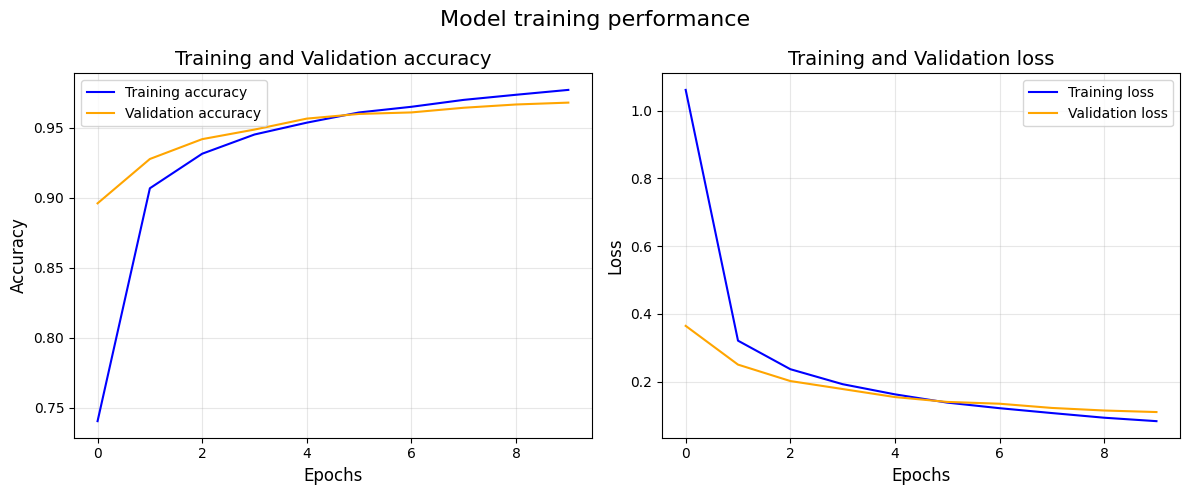

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training accuracy', color='blue')
plt.plot(
  mod.history['val_accuracy'],
  label='Validation accuracy', color='orange'
)
plt.title('Training and Validation accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation loss', color='orange')
plt.title('Training and Validation loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("Model training performance", fontsize=16)
plt.tight_layout();

## Multi-layer perceptron

We will be using the Digits data set, with the goal of classifying hand-written digits (8x8 pixel images).

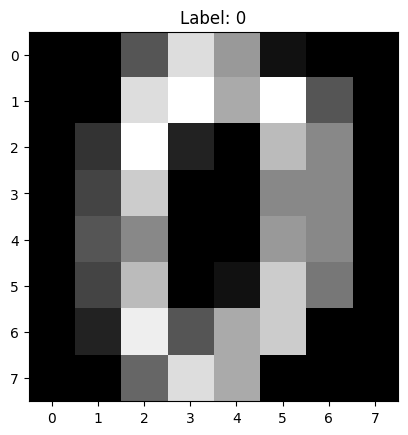

In [15]:
digits = load_digits()
X = digits.data
y = digits.target

# visualise sample
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Label: {y[0]}")

X_trn, X_tst, y_trn, y_tst = train_test_split(
  X, y, test_size=0.2, random_state=SEED
)

# standardise pixel values (critical for NNs)
scaler = StandardScaler()
X_trn = scaler.fit_transform(X_trn)
X_tst = scaler.transform(X_tst)

## Simple neural network: multilayer perceptron

We define a network with two hidden layers: 64 neurons and 32 neurons each, respectively.
We will use the Adam solver (a variation of gradient descent).

In [16]:
mlp = MLPClassifier(
  hidden_layer_sizes=(64, 32),
  max_iter=500,
  activation='relu',
  solver='adam',
  random_state=SEED,
  verbose=False
)

# train model (back-propagation)
mlp.fit(X_trn, y_trn)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## Evaluation

--- Neural Network classification report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      1.00      0.98        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



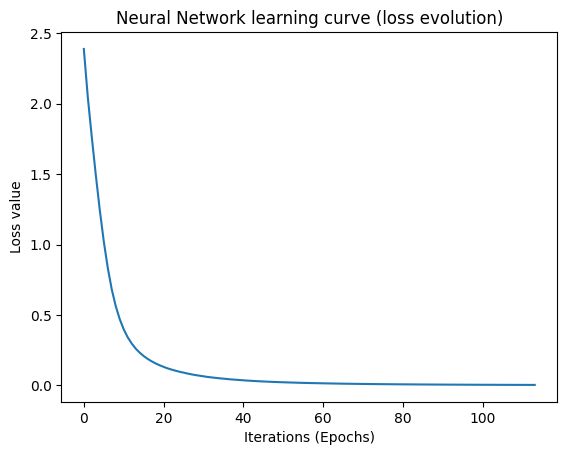

In [17]:
y_pred = mlp.predict(X_tst)

print("--- Neural Network classification report ---")
print(classification_report(y_tst, y_pred))

# plot Loss curve to see convergence
plt.plot(mlp.loss_curve_)
plt.title("Neural Network learning curve (loss evolution)")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss value");

## Data augmentation

This is a strategy to help to train a NN with small data sets.

We will artificially double the data set by adding slight noise to the images.

In [18]:
def augment_data(data, noise_level=0.1):
  noise = np.random.normal(0, noise_level, data.shape)
  return data + noise

X_augmented = augment_data(X_trn)
X_combined = np.vstack((X_trn, X_augmented))
y_combined = np.hstack((y_trn, y_trn))

print(f"\nOriginal training size: {X_trn.shape[0]}")
print(f"Augmented training size: {X_combined.shape[0]}")


Original training size: 1437
Augmented training size: 2874


--- Neural Network classification report (data augmentation) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.94      0.97      0.96        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.93      0.95        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



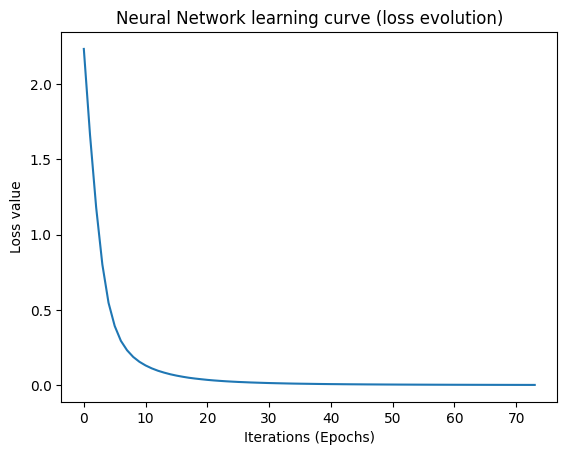

In [19]:
# train model
mlp.fit(X_combined, y_combined)
y_pred_aug = mlp.predict(X_tst)

print("--- Neural Network classification report (data augmentation) ---")
print(classification_report(y_tst, y_pred_aug))

# plot Loss curve to see convergence
plt.plot(mlp.loss_curve_)
plt.title("Neural Network learning curve (loss evolution)")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss value");

## Modular networks

### Keras/TensorFlow

In [20]:
# create model
model_ktf = models.Sequential([
  layers.Input(shape=(64,)),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.2), # regularisation strategy for small data
  layers.Dense(64, activation='relu'),
  layers.Dense(10, activation='softmax') # 10 classes for digits
])

# convert labels to categorical for Keras
y_trn_cat = to_categorical(y_trn, num_classes=10)
y_tst_cat = to_categorical(y_tst, num_classes=10)

# compile model
model_ktf.compile(
  optimizer=Adam(learning_rate=LR),
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

# reproducibility
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# train model
history = model_ktf.fit(
  X_trn, y_trn_cat,
  validation_data=(X_tst, y_tst_cat),
  epochs=20, batch_size=32
)

Epoch 1/20


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5358 - loss: 1.5961 - val_accuracy: 0.8028 - val_loss: 0.8056
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8636 - loss: 0.5822 - val_accuracy: 0.9139 - val_loss: 0.3100
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.9318 - loss: 0.2890 - val_accuracy: 0.9472 - val_loss: 0.1870
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9562 - loss: 0.1933 - val_accuracy: 0.9639 - val_loss: 0.1344
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9701 - loss: 0.1338 - val_accuracy: 0.9694 - val_loss: 0.1117
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9756 - loss: 0.0995 - val_accuracy: 0.9722 - val_loss: 0.0920
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.9756 - loss: 0.0886 - val_accuracy: 0.9750 - val_loss: 0.0874
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.9882 - loss: 0.0648 - val_accuracy: 0.9806 - val_loss: 0.

In [21]:
# evaluate
loss, acc = model_ktf.evaluate(X_tst, y_tst_cat)
print(f"Keras test accuracy: {acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.9833 - loss: 0.0756
Keras test accuracy: 0.9833


In [22]:
# predictions for testing set
y_pred_probs_keras = model_ktf.predict(X_tst) # shape [n_samples, n_classes]

# convert to DataFrame
df_probs_keras = pd.DataFrame(
  y_pred_probs_keras, columns=[f"Class_{i}" for i in range(10)]
)
df_probs_keras["True label"] = y_tst
df_probs_keras.head(5)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Class_0,Class_1,Class_2,Class_3,Class_4,Class_5,Class_6,Class_7,Class_8,Class_9,True label
0,4.762866e-06,4.644232e-07,1.364043e-07,3.977252e-07,2.583850e-05,6.360630e-06,9.997659e-01,7.030803e-07,0.000195,9.352254e-07,6
1,2.155962e-05,2.318062e-07,2.274223e-08,3.699904e-06,4.599819e-05,1.420297e-02,2.946854e-08,9.915783e-06,0.000007,9.857088e-01,9
2,8.031194e-11,5.264653e-08,1.860984e-07,9.999914e-01,1.282757e-10,6.597740e-08,5.385870e-09,4.597153e-08,0.000005,3.691296e-06,3
3,9.364283e-06,4.935595e-06,5.012315e-06,1.103919e-05,2.831000e-04,2.280026e-04,5.506988e-08,9.961752e-01,0.000059,3.224752e-03,7
4,5.708975e-07,6.491151e-06,9.992998e-01,4.200061e-04,2.515417e-09,1.139973e-07,1.870056e-06,4.845001e-07,0.000271,6.289718e-08,2


Each row corresponds to one test sample:
- Columns `Class_0` ... `Class_9`: predicted probabilities.
- `True label`: actual digit.

### PyTorch

In [23]:
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(64, 128)
    self.dropout = nn.Dropout(0.2) # regularisation for small data
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10) # 10 classes for digits

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return F.softmax(x, dim=1) # softmax along class dimension

In [24]:
# convert data to tensors
X_trn_t = torch.tensor(X_trn, dtype=torch.float32)
y_trn_t = torch.tensor(y_trn, dtype=torch.long)
X_tst_t = torch.tensor(X_tst, dtype=torch.float32)
y_tst_t = torch.tensor(y_tst, dtype=torch.long)

# PyTorch data loader
trn_dataset = TensorDataset(X_trn_t, y_trn_t)
tst_dataset = TensorDataset(X_tst_t, y_tst_t)
trn_loader = DataLoader(trn_dataset, batch_size=32, shuffle=True)
tst_loader = DataLoader(tst_dataset, batch_size=32)

In [25]:
# instantiate the model
model_t = SimpleMLP()
print(model_t)

# loss and optimiser
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model_t.parameters(), lr=LR)

# reproducibility
np.random.seed(SEED)
random.seed(SEED)
# select device depending on architecture
if torch.backends.mps.is_available():
  device = torch.device('mps') # Apple silicon GPU
elif torch.cuda.is_available():
  device = torch.device('cuda') # Nvidia GPU
else:
  device = torch.device('cpu') # CPU fallback
# ensure reproducibility on GPU
if device.type in ['cuda', 'mps']:
  torch.manual_seed(SEED)
  if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print(f"\nUsing {str(device).upper()} device.\n")

# training loop
torch_losses = []
for epoch in range(20):
  model_t.train()
  for X_batch, y_batch in trn_loader:
    optimiser.zero_grad()
    outputs = model_t(X_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimiser.step()
    torch_losses.append(loss.item())

  print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

SimpleMLP(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Using MPS device.

Epoch 1: loss = 2.0964
Epoch 2: loss = 1.7443
Epoch 3: loss = 1.6435
Epoch 4: loss = 1.4804
Epoch 5: loss = 1.5103
Epoch 6: loss = 1.5423
Epoch 7: loss = 1.4938
Epoch 8: loss = 1.4810
Epoch 9: loss = 1.4710
Epoch 10: loss = 1.4706
Epoch 11: loss = 1.4630
Epoch 12: loss = 1.4623
Epoch 13: loss = 1.4658
Epoch 14: loss = 1.4982
Epoch 15: loss = 1.4624
Epoch 16: loss = 1.4704
Epoch 17: loss = 1.4670
Epoch 18: loss = 1.4624
Epoch 19: loss = 1.4614
Epoch 20: loss = 1.4641


In [26]:
# evaluation
model_t.eval()
correct = 0
total = 0
with torch.no_grad():
  for X_batch, y_batch in tst_loader:
    outputs = model_t(X_batch)
    _, predicted = torch.max(outputs, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

print(f"PyTorch test accuracy: {correct/total:.4f}")

PyTorch test accuracy: 0.9750


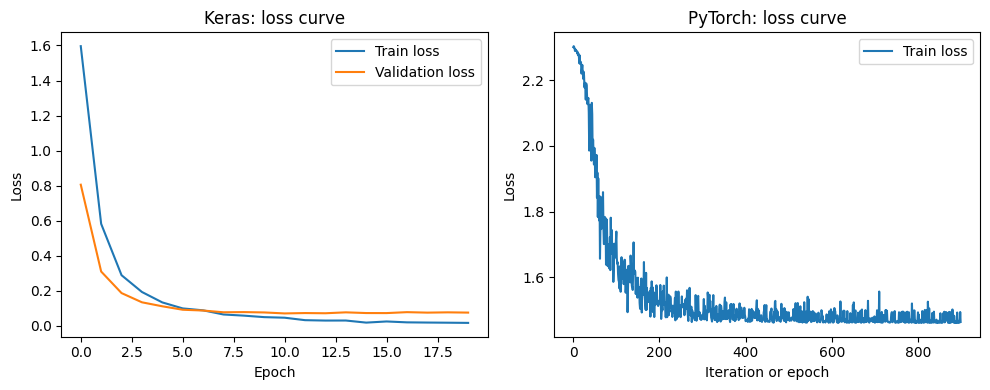

In [27]:
# Keras loss curve
keras_loss = history.history['loss']
keras_val_loss = history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(keras_loss, label='Train loss')
plt.plot(keras_val_loss, label='Validation loss')
plt.title('Keras: loss curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# PyTorch loss curve
plt.subplot(1, 2, 2)
plt.plot(torch_losses, label='Train loss')
plt.title('PyTorch: loss curve')
plt.xlabel('Iteration or epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout();

Using MPS device.

Epoch 1/20, Train loss: 1.8828, Validation loss: 1.1865
Epoch 2/20, Train loss: 0.7274, Validation loss: 0.3743
Epoch 3/20, Train loss: 0.2853, Validation loss: 0.2098
Epoch 4/20, Train loss: 0.1677, Validation loss: 0.1563
Epoch 5/20, Train loss: 0.1225, Validation loss: 0.1337
Epoch 6/20, Train loss: 0.0943, Validation loss: 0.1171
Epoch 7/20, Train loss: 0.0696, Validation loss: 0.1109
Epoch 8/20, Train loss: 0.0592, Validation loss: 0.1036
Epoch 9/20, Train loss: 0.0520, Validation loss: 0.1037
Epoch 10/20, Train loss: 0.0400, Validation loss: 0.0928
Epoch 11/20, Train loss: 0.0300, Validation loss: 0.0926
Epoch 12/20, Train loss: 0.0301, Validation loss: 0.0923
Epoch 13/20, Train loss: 0.0249, Validation loss: 0.0898
Epoch 14/20, Train loss: 0.0232, Validation loss: 0.0896
Epoch 15/20, Train loss: 0.0185, Validation loss: 0.0940
Epoch 16/20, Train loss: 0.0172, Validation loss: 0.0929
Epoch 17/20, Train loss: 0.0177, Validation loss: 0.0921
Epoch 18/20, Train lo

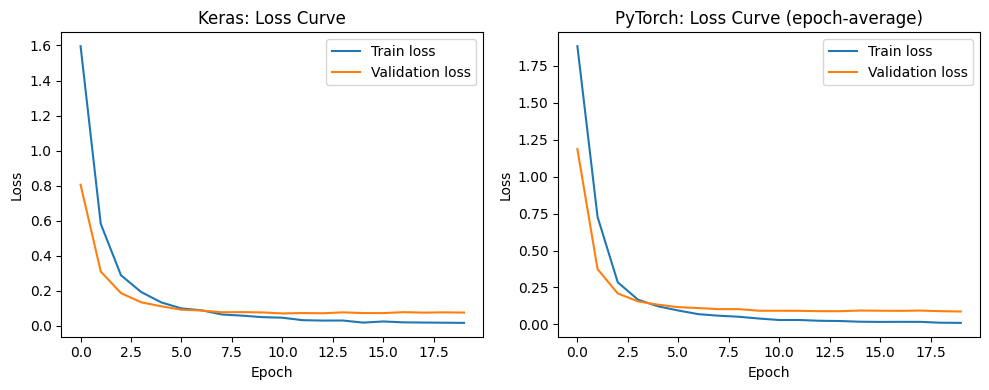

In [28]:
# reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# select device
if torch.backends.mps.is_available():
  device = torch.device('mps')
elif torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(f"Using {str(device).upper()} device.\n")

# PyTorch data set
X_trn_t = torch.tensor(X_trn, dtype=torch.float32)
y_trn_t = torch.tensor(y_trn, dtype=torch.long)
X_tst_t = torch.tensor(X_tst, dtype=torch.float32)
y_tst_t = torch.tensor(y_tst, dtype=torch.long)

trn_dataset = TensorDataset(X_trn_t, y_trn_t)
tst_dataset = TensorDataset(X_tst_t, y_tst_t)
trn_loader = DataLoader(trn_dataset, batch_size=32, shuffle=True)
tst_loader = DataLoader(tst_dataset, batch_size=32)

# model
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(64, 128)
    self.dropout = nn.Dropout(0.2)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x) # raw logits
    return x

model_t = SimpleMLP().to(device)

# loss and optimiser
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model_t.parameters(), lr=LR)

# training loop with epoch-average losses
n_epochs = 20
epoch_losses = []
val_losses = []

for epoch in range(n_epochs):
  model_t.train()
  running_loss = 0.0
  for X_batch, y_batch in trn_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    optimiser.zero_grad()
    outputs = model_t(X_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimiser.step()
    running_loss += loss.item() * X_batch.size(0) # sum loss over batch
  epoch_loss = running_loss / len(trn_loader.dataset) # average loss
  epoch_losses.append(epoch_loss)

  # validation
  model_t.eval()
  val_running_loss = 0.0
  with torch.no_grad():
    for X_val, y_val in tst_loader:
      X_val, y_val = X_val.to(device), y_val.to(device)
      outputs = model_t(X_val)
      val_loss = criterion(outputs, y_val)
      val_running_loss += val_loss.item() * X_val.size(0)
  val_epoch_loss = val_running_loss / len(tst_loader.dataset)
  val_losses.append(val_epoch_loss)

  print(
    f"Epoch {epoch+1}/{n_epochs}, "
    f"Train loss: {epoch_loss:.4f}, "
    f"Validation loss: {val_epoch_loss:.4f}"
  )

# evaluation
model_t.eval()
correct = 0
total = 0
with torch.no_grad():
  for X_batch, y_batch in tst_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    outputs = model_t(X_batch)
    _, predicted = torch.max(outputs, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()
print(f"\nPyTorch test accuracy: {correct/total:.4f}")

# plot Keras vs PyTorch loss curves
plt.figure(figsize=(10, 4))

# Keras
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.title('Keras: Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# PyTorch
plt.subplot(1,2,2)
plt.plot(epoch_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.title("PyTorch: Loss Curve (epoch-average)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout();

## Visualise PyTorch predictions as probabilities

PyTorch models output **logits**.
We apply **softmax** to convert them into probabilities.

In [29]:
# take small batch from test set
X_sample, y_sample = next(iter(tst_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

# get raw logits from model
model_t.eval()
with torch.no_grad():
  logits = model_t(X_sample)

# convert to probabilities
probs = F.softmax(logits, dim=1) # shape [batch_size, 10]

# convert to pandas DataFrame
df_probs = pd.DataFrame(
  probs.cpu().numpy(), columns=[f"Class {i}" for i in range(10)]
)
df_probs["True label"] = y_sample.cpu().numpy()
df_probs.head(5)

,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,True label
0,5.065593e-06,2.808177e-07,3.733248e-09,2.502015e-08,3.954991e-06,3.634009e-07,9.997783e-01,8.170759e-09,2.116230e-04,3.510800e-07,6
1,3.997112e-05,2.477217e-07,6.417628e-09,2.935262e-06,1.589357e-06,1.664988e-02,1.058560e-09,3.014298e-06,1.036058e-06,9.833014e-01,9
2,4.953528e-12,3.558192e-10,6.036884e-07,9.999970e-01,5.901024e-12,7.999940e-08,2.712246e-11,7.623959e-09,5.491422e-07,1.760450e-06,3
3,1.094854e-05,1.694587e-05,8.602776e-07,1.471547e-05,4.558724e-05,3.109463e-04,4.194824e-08,9.985632e-01,1.917469e-06,1.034679e-03,7
4,1.583049e-10,1.311229e-07,9.958119e-01,4.178014e-03,7.953133e-11,2.755677e-08,7.074789e-09,4.344028e-09,9.501735e-06,3.968843e-07,2


Each row shows **predicted probabilities for all classes**.
We can format the numbers for easy reading:

In [30]:
df_probs_formatted = df_probs.copy()
prob_cols = [f"Class {i}" for i in range(10)]
df_probs_formatted[prob_cols] = df_probs_formatted[prob_cols].apply(
  lambda col: col.map(lambda x: f"{x:.5f}")
)

# display the first 5 rows
df_probs_formatted.head(15)

,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,True label
0,0.00001,0.00000,0.00000,0.00000,0.00000,0.00000,0.99978,0.00000,0.00021,0.00000,6
1,0.00004,0.00000,0.00000,0.00000,0.00000,0.01665,0.00000,0.00000,0.00000,0.98330,9
2,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,3
3,0.00001,0.00002,0.00000,0.00001,0.00005,0.00031,0.00000,0.99856,0.00000,0.00103,7
4,0.00000,0.00000,0.99581,0.00418,0.00000,0.00000,0.00000,0.00000,0.00001,0.00000,2
5,0.00000,0.67454,0.31896,0.00000,0.00002,0.00019,0.00105,0.00000,0.00519,0.00005,1
6,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,5
7,0.00000,0.00001,0.99469,0.00529,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001,2
8,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,5
9,0.00000,0.00000,0.93423,0.06577,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2


,Class 0,Class 1,Class 2
Index 0,0.1863,0.3072,0.5065
Index 1,0.2312,0.6285,0.1402
Index 2,0.6285,0.1402,0.2312
Index 3,0.8438,0.1142,0.0420


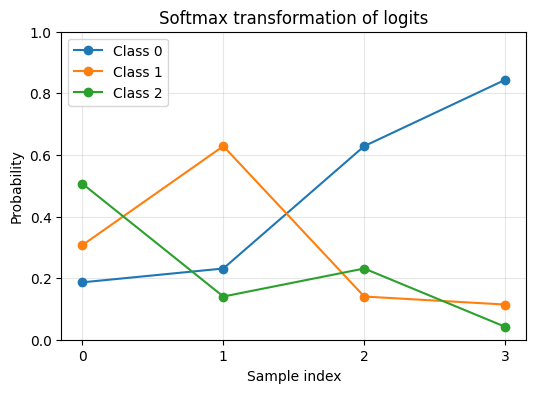

In [31]:
# varying logits for 3 classes
logits = np.array([
  [0.5, 1.0, 1.5],
  [1.0, 2.0, 0.5],
  [2.0, 0.5, 1.0],
  [3.0, 1.0, 0.0],
])

# convert to torch tensor
logits_t = torch.tensor(logits, dtype=torch.float32)

# apply softmax
probs_t = F.softmax(logits_t, dim=1)
probs = probs_t.numpy()

# plot
plt.figure(figsize=(6, 4))
for i in range(probs.shape[1]):
  plt.plot(range(len(probs)), probs[:,i], marker='o', label=f'Class {i}')
plt.title('Softmax transformation of logits')
plt.xlabel('Sample index')
plt.ylabel('Probability')
plt.xticks(range(len(probs)))
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3);

# turn probs into Pandas DataFrame
# probs: shape (num_samples, num_classes)
num_samp, num_class = probs.shape
# row and column labels
row_labs = [f"Index {i}" for i in range(num_samp)]
col_labs = [f"Class {i}" for i in range(num_class)]
# create data frame
df_probs_labs = pd.DataFrame(
  probs, index=row_labs, columns=col_labs
)
# format numbers to four decimal places
df_probs_labs = df_probs_labs.apply(
  lambda col: col.map(lambda x: f"{x:.4f}")
)
df_probs_labs

### 3D plot

#### Matplotlib

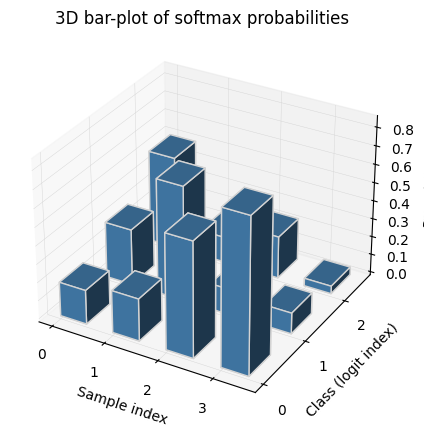

In [115]:
# prepare data
_x = np.arange(num_samp) # sample indices for x-axis
_y = np.arange(num_class) # sample indices / logits for y-axis

# create grid
_xx, _yy = np.meshgrid(_x, _y)
x, y = _xx.ravel(), _yy.ravel()
z = np.zeros_like(x) # bottom of bars
dx = dy = 0.5 # width of bars
dz = probs.T.ravel() # heights = probabilities

# create 3D plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(
  x, y, z, dx, dy, dz,
  shade=True, color='steelblue', edgecolor='lightgrey'
)
# configure grid lines
ax.xaxis._axinfo['grid'].update(
  {'color': 'lightgray', 'alpha': 0.15, 'linewidth': 0.3}
)
ax.yaxis._axinfo['grid'].update(
  {'color': 'lightgray', 'alpha': 0.15, 'linewidth': 0.3}
)
ax.zaxis._axinfo['grid'].update(
  {'color': 'lightgray', 'alpha': 0.15, 'linewidth': 0.3}
)

ax.set_xlabel("Sample index")
ax.set_ylabel("Class (logit index)")
ax.set_zlabel("Progability")
ax.set_title("3D bar-plot of softmax probabilities")
# adjust x-ticks and y-ticks for clarity
ax.set_xticks(np.arange(num_samp))
ax.set_yticks(np.arange(num_class));

#### Plotly

In [114]:
# Create a 3D figure
fig = go.Figure()

# Mesh3d workaround for 3D bars
for i in range(num_class):
  for j in range(num_samp):
    # Define the 8 vertices of the cuboid
    x0, x1 = j - 0.25, j + 0.25
    y0, y1 = i - 0.25, i + 0.25
    z0, z1 = 0, probs[j, i]
    
    # Vertices of the cuboid
    x = [x0, x1, x1, x0, x0, x1, x1, x0]
    y = [y0, y0, y1, y1, y0, y0, y1, y1]
    z = [z0, z0, z0, z0, z1, z1, z1, z1]
    
    # Triangles for the 12 faces (2 per rectangular face)
    i_vals = [0, 0, 4, 4, 0, 0, 1, 1, 0, 0, 3, 3]
    j_vals = [1, 2, 5, 6, 1, 3, 2, 5, 3, 4, 2, 6]
    k_vals = [2, 3, 6, 7, 3, 4, 5, 6, 4, 7, 6, 7]
    
    fig.add_trace(go.Mesh3d(
      x=x, y=y, z=z,
      i=i_vals, j=j_vals, k=k_vals,
      color=['steelblue', 'coral', 'mediumseagreen'][i],
      opacity=0.8,
      name=f'Class {i}' if j == 0 else None,
      showlegend=(j == 0)
    ))

# Lighter grid and layout
fig.update_layout(
  scene=dict(
    xaxis=dict(
      title="Sample Index",
      tickvals=list(range(num_samp)),
      gridcolor='rgba(200,200,200,0.2)'
    ),
    yaxis=dict(
      title="Class (logit index)",
      tickvals=list(range(num_class)),
      gridcolor='rgba(200,200,200,0.2)'
    ),
    zaxis=dict(
      title="Probability",
      gridcolor='rgba(200,200,200,0.2)'
    ),
  ),
  title="3D bar-plot of softmax probabilities",
  width=800,
  height=600,
)

### Heatmap

In [120]:
x = np.arange(num_samp)
y = np.arange(num_class)

# prepare data for heatmap style
fig = go.Figure(
  data=[
    go.Heatmap(
      x=x,       # sample indices
      y=y,       # class indices
      z=probs.T, # probabilities
      colorscale='Blues',
      zmin=0,
      zmax=1
    )
  ]
)

fig.update_layout(
   title='Interactive heatmap of softmax probabilities',
   xaxis=dict(
    title="Sample index",
    tickmode='array',
    tickvals=list(range(num_samp)),
    ticktext=[str(i) for i in range(num_samp)],
    dtick=1
   ),
   yaxis=dict(
    title="Class / Logit index",
    tickmode='array',
    tickvals=list(range(num_class)),
    ticktext=[str(i) for i in range(num_class)],
    dtick=1
   ),
   width=800,
   height=600
)

## Convolution neural network

In [34]:
# device configuration
device = (
  torch.device('cuda') if torch.cuda.is_available()
  else torch.device('mps') if torch.backends.mps.is_available()
  else torch.device('cpu')
)

print(f'Using device: {device}')

Using device: mps


100.0%
100.0%
100.0%
100.0%


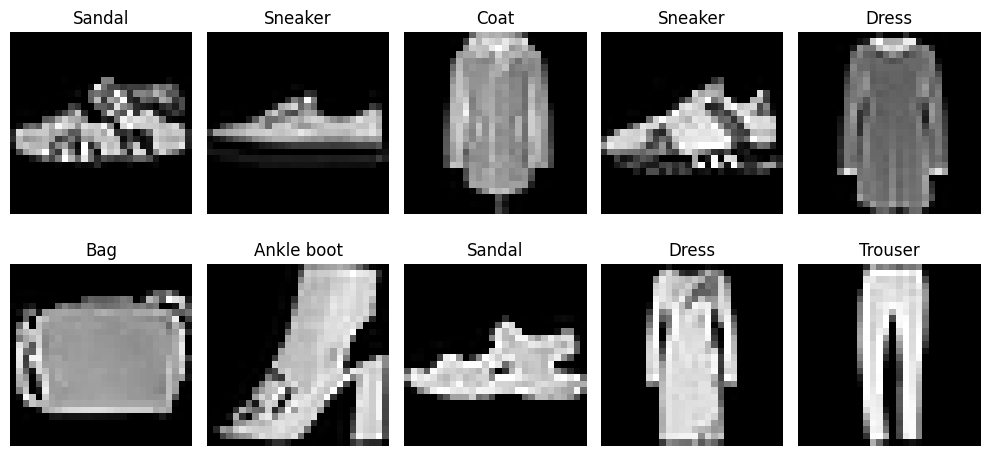

In [38]:
# data preparation

# Fashion-MNIST images are:
# - grayscale
# - size 28x28
# - pixel range [0, 255]

# convert images to tensors and normalise them
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

# download training data
trn_dat = datasets.FashionMNIST(
  root='./data',
  train=True,
  transform=transform,
  download=True
)

# download testing data
tst_dat = datasets.FashionMNIST(
  root='./data',
  train=False,
  transform=transform,
  download=True
)

# create data loaders
trn_loader = DataLoader(
  trn_dat,
  batch_size=64,
  shuffle=True
)

tst_loader = DataLoader(
  tst_dat,
  batch_size=64,
  shuffle=False
)

# fashion-MNIST class names
class_names = [
  'T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'
]

# visualise sample images
images, labels = next(iter(trn_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
  # convert tensor to NumPy array
  image = images[i].squeeze().numpy()
  ax.imshow(image, cmap='gray')
  ax.set_title(class_names[labels[i]])
  ax.axis('off')

plt.tight_layout();

In [40]:
# define CNN architecture
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    # first convolutional block
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )

    # second convolutional block
    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )

    # fully connected classifier
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(64 * 7 * 7, 128),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

# create model instance
model = CNN().to(device)
print(model)

# loss function and optimiser
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(
  model.parameters(),
  lr=0.001
)
# training loop
EPOCHS = 10

trn_loss = []
trn_accu = []

for epoch in range(EPOCHS):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in trn_loader:
    # move tensors to device
    images = images.to(device)
    labels = labels.to(device)

    # clear previous gradients
    optimiser.zero_grad()

    # forward pass
    outputs = model(images)

    # compute loss
    loss = criterion(outputs, labels)

    # backpropagation
    loss.backward()

    # update weights
    optimiser.step()

    # accumulate loss
    running_loss += loss.item()

    # predictions
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  # compute epoch statistics
  epoch_loss = running_loss / len(trn_loader)
  epoch_accu = correct / total
  trn_loss.append(epoch_loss)
  trn_accu.append(epoch_accu)

  print(
    f'Epoch [{epoch + 1}/{EPOCHS}] | '
    f'Loss: {epoch_loss:.4f} | '
    f'Accuracy: {epoch_accu:.4f}'
  )

CNN(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch [1/10] | Loss: 0.4831 | Accuracy: 0.8255
Epoch [2/10] | Loss: 0.3166 | Accuracy: 0.8859
Epoch [3/10] | Loss: 0.2706 | Accuracy: 0.9007
Epoch [4/10] | Loss: 0.2406 | Accuracy: 0.9126
Epoch [5/10] | Loss: 0.2134 | Accuracy: 0.9213
Epoch [6/10] | Loss: 0.1954 | Accuracy: 0.9276
Epoch [7/10] | Loss: 0.1773 | Accuracy: 0

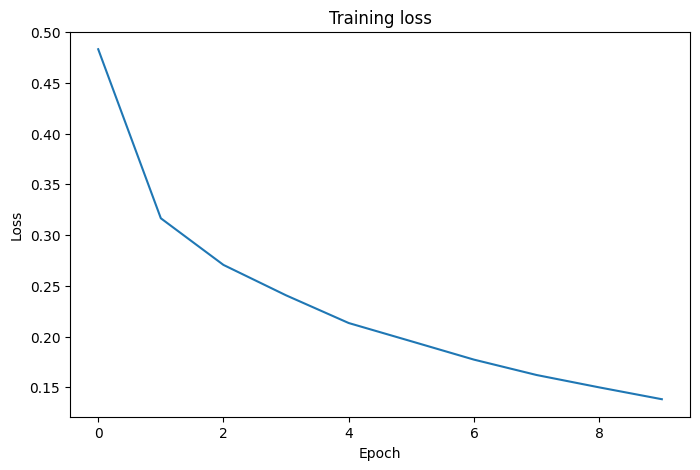

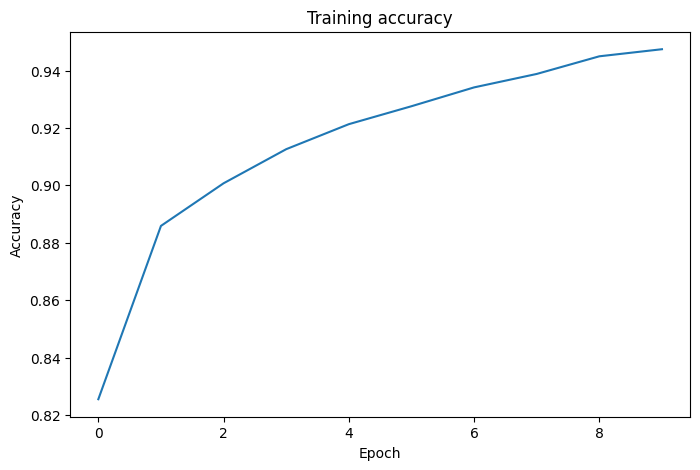


Test accuracy: 0.9212


In [42]:
# plot training metrics

# plot training loss
plt.figure(figsize=(8, 5))
plt.plot(trn_loss)
plt.title("Training loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# plot training accuracy
plt.figure(figsize=(8, 5))

plt.plot(trn_accu)

plt.title("Training accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# evaluate on test data
model.eval()

all_predictions = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
  for images, labels in tst_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_predictions.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# final test accuracy
tst_accu = correct / total
print(f'\nTest accuracy: {tst_accu:.4f}')


Classification report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.92      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.85      0.91      0.88      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.86      0.89      0.87      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.84      0.70      0.77      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



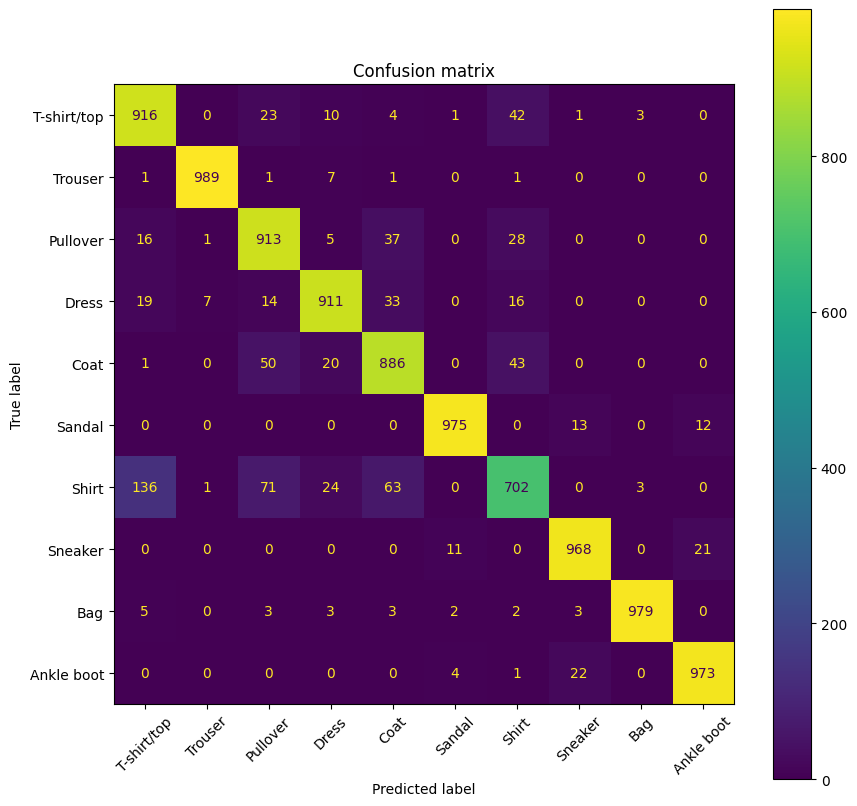

In [44]:
# classification report
print('\nClassification report:\n')

print(classification_report(
  all_labels,
  all_predictions,
  target_names=class_names
))

# confusion matrix
cm = confusion_matrix(
  all_labels,
  all_predictions
)

disp = ConfusionMatrixDisplay(
  confusion_matrix=cm,
  display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax)
plt.xticks(rotation=45)
plt.title("Confusion matrix");

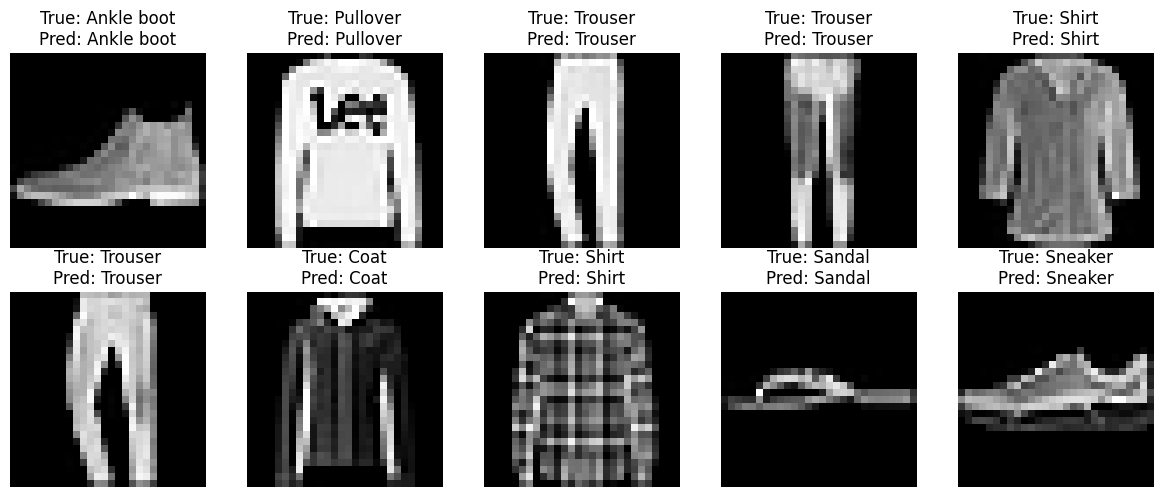

In [45]:
# visualise predictions
images, labels = next(iter(tst_loader))
images = images.to(device)
outputs = model(images)
_, predictions = torch.max(outputs, 1)
images = images.cpu()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
  image = images[i].squeeze().numpy()
  true_label = class_names[labels[i]]
  predicted_label = class_names[predictions[i]]
  ax.imshow(image, cmap='gray')
  ax.set_title(
    f"True: {true_label}\nPred: {predicted_label}"
  )
  ax.axis('off')

plt.tight_layout();